<a href="https://colab.research.google.com/github/Ono-se/hospital_readmission_classification_project/blob/main/Hospital_Readmission_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

Hospital readmissions place additional pressure on healthcare resources and can indicate challenges in patient care and recovery. Identifying patients who are likely to be readmitted shortly after discharge can help healthcare providers better understand readmission risk and support more targeted interventions.

This project investigates whether patient demographic, clinical, and hospital utilization data can be used to predict **30-day hospital readmission**. The problem is formulated as a **binary classification task**, where the target indicates whether a patient was readmitted within 30 days of discharge.

The dataset contains patient-level records with demographic information, diagnoses, medications, and healthcare utilization variables. Because 30-day readmissions represent a relatively small proportion of the observations, particular attention is given to **class imbalance and appropriate model evaluation**, including precision, recall, F1-score, and ROC-AUC.

### Objective

The objective is to develop and evaluate machine learning models that can identify patients at higher risk of 30-day readmission while examining the statistical and modeling trade-offs involved in predicting an imbalanced clinical outcome.


# **Data Cleaning**

## Dataset Overview

The dataset contains **101,766 patient encounters and 50 variables** describing demographic characteristics, hospital admission details, diagnoses, medications, and healthcare utilization.

The target variable, `readmitted`, records whether a patient was:

* **`<30`** — readmitted within 30 days
* **`>30`** — readmitted after 30 days
* **`NO`** — not readmitted

For this project, the target was transformed into a binary outcome focused on **30-day readmission**, with patients readmitted within 30 days treated as the positive class.

The dataset contains a mixture of numerical and categorical variables, including patient demographics, admission information, length of hospital stay, previous encounters, diagnoses, and medication-related features. Several variables contain missing values represented by `?`, which are addressed during the data-cleaning stage.


In [1]:
#Import Libraries
import pandas as pd

In [2]:
#Load the dataset
data = pd.read_csv('/content/drive/MyDrive/Cleaning_Data/diabetic_data.csv')
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print(data.info())
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
# Summary statistics
data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
data.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [6]:
data.isnull().sum().sum()

np.int64(181168)

In [7]:
#Converting all the '?' to null
data = data.replace("?", pd.NA)

In [8]:
#Checking for all null values and the columns with the most null values
data.isna().sum().sort_values(ascending=False).head(10)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [9]:
#Filling the columns
data["medical_specialty"] = data["medical_specialty"].fillna("Unknown")
data["max_glu_serum"] = data["max_glu_serum"].fillna("None")
data["A1Cresult"] = data["A1Cresult"].fillna("None")

In [10]:
#Check the target column
data["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [11]:
print((data["readmitted"].value_counts(normalize=True) * 100).round(2))

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [12]:
#Noticed that some columns contain '?' instead of being null
(data == "?").sum().sort_values(ascending=False)

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [13]:
#Converting the 'readmitted' column into 0/1
data["target"] = (data["readmitted"] == "<30").astype(int)

data["target"].value_counts()

,count
target,
0,90409
1,11357


In [14]:
#Dropping columns that are IDs and the'readmitted' which has been changed to 'target'
data = data.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "weight",
        "payer_code",
        "readmitted"
    ]
)

In [15]:
#Checking the distribution of the target column
data["target"].value_counts(normalize=True)

,proportion
target,
0,0.888401
1,0.111599


In [16]:
#Checking the data types
data.dtypes

,0
race,object
gender,object
age,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
medical_specialty,object
num_lab_procedures,int64
num_procedures,int64


In [17]:
#Listing the columns that are objects
data.select_dtypes(include="object").columns.tolist()

['race',
 'gender',
 'age',
 'medical_specialty',
 'diag_1',
 'diag_2',
 'diag_3',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed']

### Data Visualization

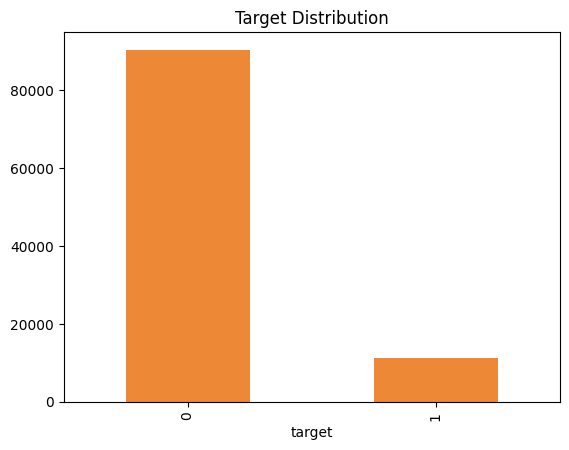

In [18]:
import matplotlib.pyplot as plt

data["target"].value_counts().plot(kind="bar", color='#ED8936')
plt.title("Target Distribution")
plt.show()

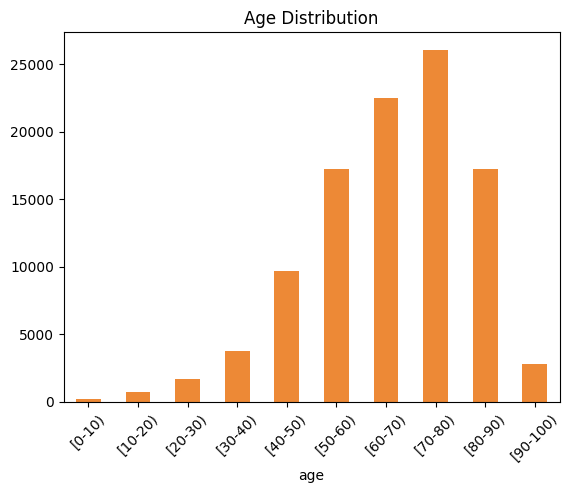

In [19]:
data["age"].value_counts().sort_index().plot(kind="bar",color='#ED8936')
plt.title("Age Distribution")
plt.xticks(rotation=45)
plt.show()

In [20]:
import seaborn as sns
import numpy as np

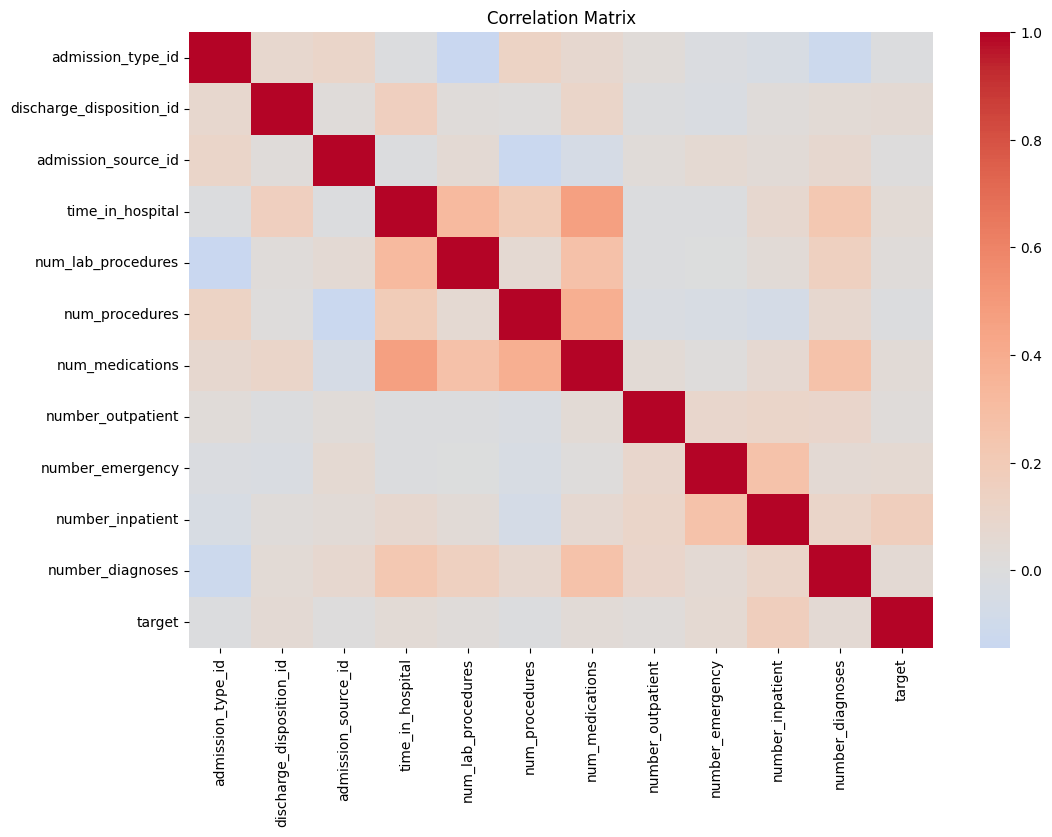

In [21]:
numeric_cols = data.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

*`time_in_hospital` has a high correlation with `num_medications` from the plot*

*`num_procedures` has a high correlation with `num_medications` from the plot*

# **Machine Learning**

In [22]:
#Loading the ml library and spliting the dataset into train and test
from sklearn.model_selection import train_test_split

X = data.drop(columns=["target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
X_train.shape, X_test.shape

((81412, 45), (20354, 45))

### Baseline Model

In [24]:
#Import libraries needed
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [25]:
#Checking all the columns that their datatype is 'object' and filling the missing data with 'unknown'
cat_cols = X_train.select_dtypes(include="object").columns

X_train[cat_cols] = X_train[cat_cols].fillna("Unknown")
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown")

Preprocessing

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
#Convert all categorical columns into one-hot encoded columns, and keep all other columns unchanged.
num_cols = X_train.select_dtypes(exclude="object").columns

cat_cols = X_train.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [28]:
model = LogisticRegression(max_iter=1000)

In [29]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [30]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazo...
       'diabetesMed'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [31]:
#Make predictions using the model, evaluate how well it performs using both classification metrics and probability-based ranking performance.
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
lr_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", lr_auc)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354

ROC-AUC: 0.6467399590220669


### Model Evaluation

*The baseline Logistic Regression model achieves an accuracy of **89%** and a ROC-AUC of **0.647**. However, accuracy is largely driven by the majority class (class 0).*

*The model correctly identifies **100% of non-readmitted patients**, but detects only **2% of patients who are readmitted**. This results in a very low F1-score of **0.04** for class 1.*

*Overall, the model shows limited ability to distinguish between readmitted and non-readmitted patients. Given the class imbalance and the importance of identifying readmissions, accuracy alone is not an appropriate measure of model performance. Recall, F1-score, and ROC-AUC provide more useful measures for evaluating this problem.*

### Baseline Model improvement

In [32]:
#Improve the model by balancing the class weights
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [33]:
lri_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

lri_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazo...
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [34]:
y_pred = lri_model.predict(X_test)
y_prob = lri_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
lr_fe_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", lr_fe_auc)

              precision    recall  f1-score   support

           0       0.92      0.65      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354

ROC-AUC: 0.6437463749339394


### Model Evaluation

*The model achieves an accuracy of 64%, with a ROC-AUC of 0.644. For the readmitted class (class 1), recall increases to 55%, meaning the model identifies more than half of the patients who are actually readmitted.*

*However, precision for class 1 is only 17%, while the F1-score is 0.26, indicating that many of the positive predictions are incorrect.*

*Compared with the previous balanced model, recall improves from 2% to 55%, but ROC-AUC decreases from 0.647 to 0.644 and overall accuracy also decreases. This indicates a trade-off between detecting more readmissions and maintaining overall predictive performance.*


### Cross Validation

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [37]:
scores = cross_val_score(
    lri_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

In [38]:
print(scores)
lr_cv = scores.mean()
print("Mean:", lr_cv)
print("Std:", scores.std())

[0.62586338 0.62728493 0.63152688 0.62655182 0.6377254 ]
Mean: 0.6297904826705241
Std: 0.004430953621296095


### Cross Validation Evaluation

*Five-fold cross-validation produced ROC-AUC scores ranging from 0.626 to 0.638, with a mean ROC-AUC of 0.63 and a standard deviation of 0.004.*

*The low standard deviation indicates that the model's performance is relatively consistent across folds. However, the mean ROC-AUC suggests that the model has limited discriminatory ability between readmitted and non-readmitted patients.*


# **Random Forest**
The second classification model being used to see if it produces better results.

In [39]:
#Import library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [41]:
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [42]:
rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazo...
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [43]:
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

In [44]:
print(classification_report(y_test, y_pred))
rf_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", rf_auc)

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.25      2271

    accuracy                           0.65     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.65      0.71     20354

ROC-AUC: 0.6531859318982997


### Model Evaluation

*The random forest classifier model achieves an accuracy of 65% and a ROC-AUC of 0.653. For the readmitted class, recall reaches 54%, meaning the model identifies more than half of the patients who are actually readmitted.*

*However, precision remains low at 17%, resulting in an F1-score of 0.25 for class 1. Compared with the previous model, the ROC-AUC increases slightly from 0.644 to 0.653, while recall decreases from 55% to 54%.*

*Overall, the new model provides a small improvement in recall but does not produce a substantial improvement in overall discrimination.*


### Hyperparameter Tuning - GridSearchCV

In [45]:
param_grid = {
    "model__n_estimators": [80,120,200],
    "model__max_depth": [8,12,16],
    "model__min_samples_leaf": [1,2,4]
}

In [46]:
grid = GridSearchCV(
    rf_clf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [47]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburid...
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               max_depth=12,
                                                               n_estimators=80,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [8, 12, 16],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__n_estimators': [80, 120, 200]},
             scoring='roc_auc')

In [48]:
rf_grid = grid.best_score_
print(grid.best_params_)
print(rf_grid)

{'model__max_depth': 16, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
0.649491761140026


### Hyperparameter Tuning

*Grid search identified the following combination as the best-performing configuration:*

* *`model_max_depth`: 16*
* *`model_min_samples`: 4*
* *`model_n_estimators`: 200*

*The best cross-validated ROC-AUC was 0.65, compared with 0.653 for the untuned model. This indicates that the selected hyperparameters did not improve cross-validation performance, with a slight decrease in ROC-AUC after tuning.*


### HistGradient Boosting

In [49]:
preprocessor_dense = ColumnTransformer(
    transformers=[
        ("categorial", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [50]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [51]:
gb_model = HistGradientBoostingClassifier(
    max_iter=150,
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

In [57]:
gb_clf = Pipeline([
    ("preprocessor", preprocessor_dense),
    ("model", gb_model)
])

In [58]:
print(gb_clf.named_steps["model"].learning_rate)

0.1


In [59]:
gb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorial',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide...
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object'))])),
                ('model',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                max_depth=3, max_iter=150,
                                                random_state=42))])

In [60]:
y_pred = gb_clf.predict(X_test)
y_prob = gb_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

hgb_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", hgb_auc)

              precision    recall  f1-score   support

           0       0.93      0.64      0.76     18083
           1       0.18      0.61      0.27      2271

    accuracy                           0.64     20354
   macro avg       0.55      0.63      0.52     20354
weighted avg       0.85      0.64      0.70     20354

ROC-AUC: 0.6754380024610331


### Model Evaluation

*After balancing the class weights, the HistGradient Boosting model achieved a ROC-AUC of 0.675, the highest of the three models tested, indicating the strongest overall discrimination between patients who were and were not readmitted.*

*At the default 0.5 threshold, the model correctly identified 61% of readmitted patients (recall). Precision for class 1 was 18%, giving an F1-score of 0.27 — the best F1 achieved across all three models so far.*

*Overall accuracy dropped to 64%. The model now makes many more positive predictions to catch readmissions, at the cost of more false positives among the majority class. Given that missed readmissions are the costlier error for this problem, this trade-off is the intended outcome of balancing.*

*Compared with the balanced Logistic Regression (recall 55%, F1 0.26, ROC-AUC 0.645) and balanced Random Forest (recall 54%, F1 0.25, ROC-AUC 0.653), the balanced HistGradient Boosting model improves on all three metrics simultaneously, making it the strongest candidate before threshold tuning.*

### Threshold Tuning

In [61]:
thresholds = np.arange(0.05, 0.90, 0.05)

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    print(f"Threshold: {threshold:.2f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Threshold: 0.05
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     18083
           1       0.11      1.00      0.20      2271

    accuracy                           0.11     20354
   macro avg       0.06      0.50      0.10     20354
weighted avg       0.01      0.11      0.02     20354

--------------------------------------------------
Threshold: 0.10
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     18083
           1       0.11      1.00      0.20      2271

    accuracy                           0.11     20354
   macro avg       0.56      0.50      0.10     20354
weighted avg       0.90      0.11      0.02     20354

--------------------------------------------------
Threshold: 0.15
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     18083
           1       0.11      1.00      0.20      2271

    accuracy                    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.53      0.04      0.07      2271

    accuracy                           0.89     20354
   macro avg       0.71      0.52      0.50     20354
weighted avg       0.85      0.89      0.84     20354

--------------------------------------------------
Threshold: 0.85
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.64      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.76      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354

--------------------------------------------------


In [62]:
#Best threshold
threshold = 0.55

y_pred_final = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85     18083
           1       0.21      0.43      0.28      2271

    accuracy                           0.76     20354
   macro avg       0.56      0.61      0.57     20354
weighted avg       0.84      0.76      0.79     20354



### Threshold Tuning

*Threshold tuning was performed to evaluate the effect of different classification thresholds on the detection of readmissions.*

*Lowering the threshold substantially increased recall for the readmitted class. At a threshold of 0.1, recall reached 100%, but precision was only 11%, resulting in many false positives and an overall accuracy of just 11%. As the threshold increased, precision improved while recall decreased.*

*The threshold of **0.55** provided the best balance based on the F1-score for the readmitted class, achieving:*

* *Precision: **21%***
* *Recall: **43%***
* *F1-score: **28%***
* *Accuracy: **76%***

*Therefore, a threshold of **0.55** was selected as the operating threshold for the model. The ROC-AUC was evaluated separately using predicted probabilities and was not affected by the selected classification threshold.*

### Visualizations

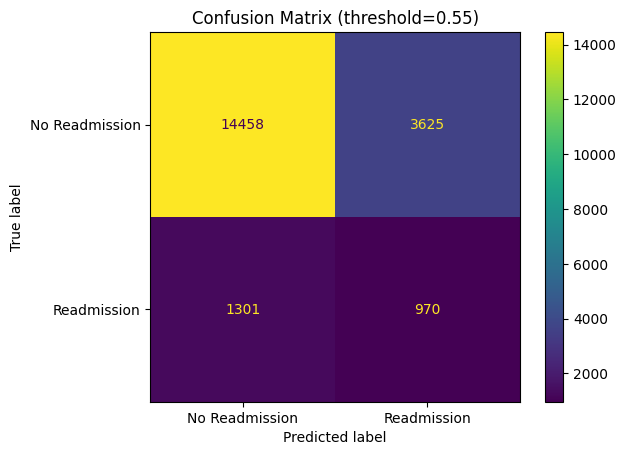

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.55
y_pred_thresh = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_thresh)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Readmission", "Readmission"])
disp.plot()
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.show()

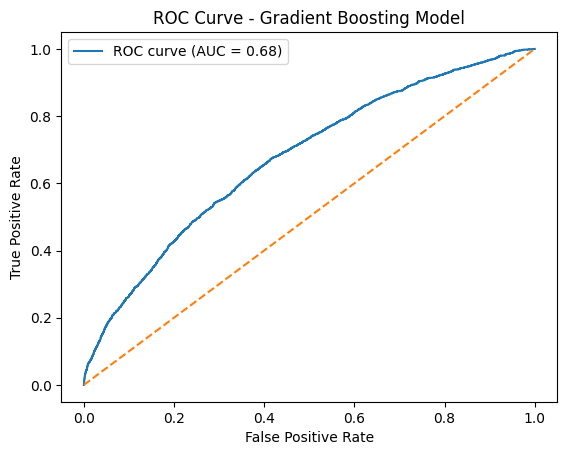

In [64]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting Model")
plt.legend()
plt.show()

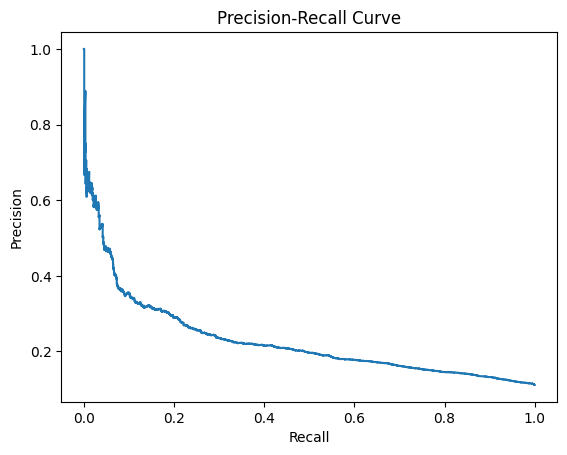

In [65]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

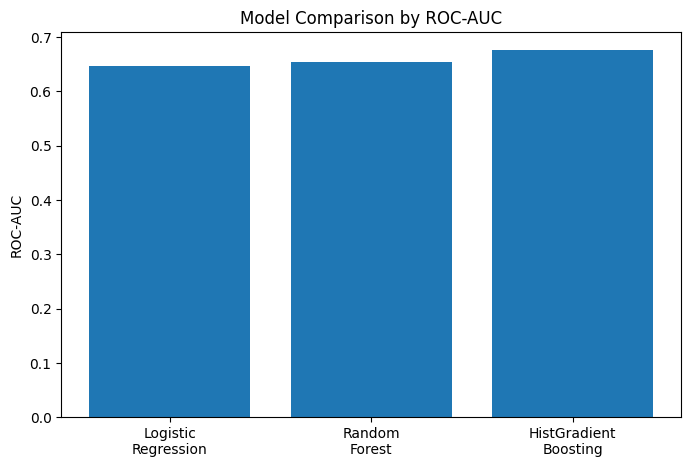

In [66]:
models = [
    "Logistic\nRegression",
    "Random\nForest",
    "HistGradient\nBoosting"
]

roc_auc = [
        lr_auc,
        rf_auc,
        hgb_auc
    ]

plt.figure(figsize=(8,5))
plt.bar(models, roc_auc)
plt.ylabel("ROC-AUC")
plt.title("Model Comparison by ROC-AUC")
plt.show()

In [67]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "HistGradient Boosting"
    ],
    "ROC_AUC":[
        lr_auc,
        rf_auc,
        hgb_auc
    ]
})

results

,Model,ROC_AUC
0,Logistic Regression,0.646740
1,Random Forest,0.653186
2,HistGradient Boosting,0.675438


### Final Model Comparison

*After applying different tuning approaches, the final models were compared using ROC-AUC to assess their overall ability to distinguish between patients who were and were not readmitted.*

| Model               |   ROC-AUC |
| ------------------- | --------: |
| Logistic Regression |     0.647 |
| Random Forest       |     0.653 |
| HistGradient Boosting   | **0.675** |

*Histogram- based Gradient Boosting achieved the highest ROC-AUC of 0.675, indicating the strongest overall discrimination among the three tuned models. Random Forest achieved a ROC-AUC of 0.653, while Logistic Regression achieved 0.647.*

*Based on ROC-AUC, **Histogram-based Gradient Boosting was selected as the final model** for further evaluation and threshold optimization. Because the dataset is imbalanced, minority-class precision, recall, and F1-score were also considered alongside ROC-AUC when evaluating the model's practical performance.*
